# CodeBERT - AI Detection

This notebook trains with CodeBERT and the AI detection dataset to generate embeddings optimized for AI detection.

The model implemented is `codeBERT`.
For better performance, the training process was done in Google Colab and the trained model was downloaded.

This program:

* Prepares the environment for Google Colab training
1. Load dataframes
2. Separates attributes and labels.
3. Imports the CodeBERT model.
4. Compiles the CodeBERT model
5. Tokenizes dataframes
6. Trains the model. **(+12h CPU & ≈2,5h GPU)**
7. Downloads model to add it to local repository
8. Loads the trained model
9. Runs validation
10. Evaluates train vs validation **(≈1h CPU & ≈10min GPU)**
11.  Plots train vs validation behavior (accuracy & loss).
12.  Makes predictions for test. **(≈X CPU & ≈1min GPU)**
13.  Evaluates test
14.  Plots the Confusion Matrix.

## Set up Google Colab for training

To train using Google Colab's GPU, you must uncomment the following code cells.

You must also ensure you are connected to a GPU runtime in Colab:
![image.png](attachment:image.png)

![image-2.png](attachment:image-2.png)

Colab's GPU has a daily execution runtime limit, which is the model and results are saved upon completing training.

In [ ]:
#!git clone https://github.com/paustelito/ai-code-analyzer.git

Cloning into 'ai-code-analyzer'...
remote: Enumerating objects: 11358, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 11358 (delta 21), reused 61 (delta 17), pack-reused 11280 (from 2)
Receiving objects: 100% (11358/11358), 29.83 MiB | 11.01 MiB/s, done.
Resolving deltas: 100% (3008/3008), done.


In [ ]:
#%cd ai-code-analyzer

/content/ai-code-analyzer


In [ ]:
#!git checkout feat/codeBERT

Updating files: 100% (9633/9633), done.
Branch 'feat/codeBERT' set up to track remote branch 'feat/codeBERT' from 'origin'.
Switched to a new branch 'feat/codeBERT'


In [ ]:
#%cd Training

/content/ai-code-analyzer/Training


## Imports

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import torch
import json
import torch
import importlib

from tqdm import tqdm

from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader

from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

## 1. Load dataframes

In [8]:
ai_train = pd.read_csv("../Dataframes/df_ai/df_ai_train.csv")
ai_val = pd.read_csv("../Dataframes/df_ai/df_ai_val.csv")
ai_test = pd.read_csv("../Dataframes/df_ai/df_ai_test.csv")

plagiarism_train = pd.read_csv("../Dataframes/df_plagiarism/df_plagiarism_train.csv")
plagiarism_val = pd.read_csv("../Dataframes/df_plagiarism/df_plagiarism_val.csv")
plagiarism_test = pd.read_csv("../Dataframes/df_plagiarism/df_plagiarism_test.csv")

print("------AI shapes------")
print("Train: ", ai_train.shape)
print("Validation: ", ai_val.shape)
print("Test: ", ai_test.shape)
print("------Plagiarism shapes------")
print("Train: ", plagiarism_train.shape)
print("Validation: ", plagiarism_val.shape)
print("Test: ", plagiarism_test.shape)

ai_train.head()

------AI shapes------
Train:  (24000, 20)
Validation:  (3000, 20)
Test:  (3000, 20)
------Plagiarism shapes------
Train:  (24000, 56)
Validation:  (3000, 56)
Test:  (3000, 56)


,code,label,approx_tokens,comment_density,avg_line_length,line_length_variance,blank_line_ratio,num_classes,num_methods,num_if,num_for,num_while,num_switch,o_complexity,max_depth,total_nodes,num_literals,num_ids,unique_ids,id_diversity
0,private Set<Integer> perNodeRelease(final C th...,0,101,0.0,61.882353,1268.339100,0.055556,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,63.0,30.0,0.476190
1,@Override\n public AuthenticationStatus for...,0,23,0.0,34.777778,702.395062,0.100000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,19.0,15.0,0.789474
2,public void callWorkListenerWithError(WorkCont...,1,28,0.0,49.500000,2072.250000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,7.0,7.0,1.000000
3,public void setSubscription(Subscription s) {\...,1,14,0.0,33.250000,500.187500,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,6.0,5.0,0.833333
4,public boolean getDialogContentInset(int theme...,1,20,0.0,44.666667,1461.222222,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,21.0,16.0,0.761905


## 2. Separate attributes and labels

In [9]:
X_ai_train = ai_train.drop("label", axis=1)
y_ai_train = ai_train["label"]

X_ai_val = ai_val.drop("label", axis=1)
y_ai_val = ai_val["label"]

X_ai_test = ai_test.drop("label", axis=1)
y_ai_test = ai_test["label"]

X_plagiarism_train = plagiarism_train.drop("label", axis=1)
y_plagiarism_train = plagiarism_train["label"]

X_plagiarism_val = plagiarism_val.drop("label", axis=1)
y_plagiarism_val = plagiarism_val["label"]

X_plagiarism_test = plagiarism_test.drop("label", axis=1)
y_plagiarism_test = plagiarism_test["label"]


print("X_ai_train:", X_ai_train.shape)
print("y_ai_train:", y_ai_train.shape)
print("X_ai_val:", X_ai_val.shape)
print("y_ai_val:", y_ai_val.shape)
print("X_ai_test:", X_ai_test.shape)
print("y_ai_test:", y_ai_test.shape)

print("X_plagiarism_train:", X_plagiarism_train.shape)
print("y_plagiarism_train:", y_plagiarism_train.shape)
print("X_plagiarism_val:", X_plagiarism_val.shape)
print("y_plagiarism_val:", y_plagiarism_val.shape)
print("X_plagiarism_test:", X_plagiarism_test.shape)
print("y_plagiarism_test:", y_plagiarism_test.shape)

print("\nTraining class distribution:")
print(y_ai_train.value_counts().sort_index())
print("\nValidation class distribution:")
print(y_ai_val.value_counts().sort_index())
print("\nTesting class distribution:")
print(y_ai_test.value_counts().sort_index())

print("\nTraining class distribution:")
print(y_plagiarism_train.value_counts().sort_index())
print("\nValidation class distribution:")
print(y_plagiarism_val.value_counts().sort_index())
print("\nTesting class distribution:")
print(y_plagiarism_test.value_counts().sort_index())


X_ai_train: (24000, 19)
y_ai_train: (24000,)
X_ai_val: (3000, 19)
y_ai_val: (3000,)
X_ai_test: (3000, 19)
y_ai_test: (3000,)
X_plagiarism_train: (24000, 55)
y_plagiarism_train: (24000,)
X_plagiarism_val: (3000, 55)
y_plagiarism_val: (3000,)
X_plagiarism_test: (3000, 55)
y_plagiarism_test: (3000,)

Training class distribution:
label
0    12000
1    12000
Name: count, dtype: int64

Validation class distribution:
label
0    1500
1    1500
Name: count, dtype: int64

Testing class distribution:
label
0    1500
1    1500
Name: count, dtype: int64

Training class distribution:
label
0    12000
1    12000
Name: count, dtype: int64

Validation class distribution:
label
0    1500
1    1500
Name: count, dtype: int64

Testing class distribution:
label
0    1500
1    1500
Name: count, dtype: int64


## 3. Import model

In [10]:
sys.path.append(os.path.abspath("../Dataset/conplag_version_2/"))

from scripts.codebert import create_model

tokenizer, model = create_model()

print(type(model))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<class 'transformers.models.roberta.modeling_roberta.RobertaForSequenceClassification'>


## 4. Compile model

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5
)

print(device)

cuda


In [12]:
print(model)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

## 5. Tokenize datasets

In [13]:
class CodeAiDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.codes = dataframe["code"].tolist()
        self.labels = dataframe["label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.codes)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.codes[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx]).long()
        }

In [14]:
ai_train_tokenized = CodeAiDataset(ai_train, tokenizer)
ai_val_tokenized = CodeAiDataset(ai_val, tokenizer)
ai_test_tokenized = CodeAiDataset(ai_test, tokenizer)

ai_train_loader = DataLoader(
    ai_train_tokenized,
    batch_size=8,
    shuffle=True
)

ai_val_loader = DataLoader(
    ai_val_tokenized,
    batch_size=8,
    shuffle=True
)

ai_test_loader = DataLoader(
    ai_test_tokenized,
    batch_size=8,
    shuffle=False
)

## 6. Train CodeBERT with datasets

In [15]:
epochs = 3

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(ai_train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = total_loss / len(ai_train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch {epoch + 1}/{epochs}")
    print(f"Train Loss: {epoch_loss:.4f}")
    print(f"Train Accuracy: {epoch_accuracy:.4f}")

100%|██████████| 3000/3000 [40:56<00:00,  1.22it/s]


Epoch 1/3
Train Loss: 0.0347
Train Accuracy: 0.9893


100%|██████████| 3000/3000 [41:06<00:00,  1.22it/s]


Epoch 2/3
Train Loss: 0.0119
Train Accuracy: 0.9963


100%|██████████| 3000/3000 [41:17<00:00,  1.21it/s]

Epoch 3/3
Train Loss: 0.0075
Train Accuracy: 0.9980


## 7. Download model and add it to local repository

To save the model trained in Google Colab, use the following commented code

In [16]:
%cd /content/ai-code-analyzer

/content/ai-code-analyzer


In [17]:
!mkdir -p models/codebert_ai_detector

In [18]:
model.save_pretrained("models/codebert_ai_detector")
tokenizer.save_pretrained("models/codebert_ai_detector")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('models/codebert_ai_detector/tokenizer_config.json',
 'models/codebert_ai_detector/tokenizer.json')

In [19]:
!ls models/codebert_ai_detector

config.json  model.safetensors	tokenizer_config.json  tokenizer.json


In [20]:
!zip -r codebert_model.zip /content/ai-code-analyzer/models/codebert_ai_detector

  adding: content/ai-code-analyzer/models/codebert_ai_detector/ (stored 0%)
  adding: content/ai-code-analyzer/models/codebert_ai_detector/model.safetensors (deflated 7%)
  adding: content/ai-code-analyzer/models/codebert_ai_detector/tokenizer.json (deflated 82%)
  adding: content/ai-code-analyzer/models/codebert_ai_detector/config.json (deflated 51%)
  adding: content/ai-code-analyzer/models/codebert_ai_detector/tokenizer_config.json (deflated 51%)


In [21]:
!ls -lh codebert_model.zip

-rw-r--r-- 1 root root 443M Jun 10 01:10 codebert_model.zip


### Important
Add the dowloadad folder content codebert_ai_detector to the local repository to save changes

## 8. Load the trained model

In [22]:
model_path = "models/codebert_ai_detector"

tokenizer = AutoTokenizer.from_pretrained(model_path)

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    output_hidden_states=True
)

model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

## 9. EMBEDDINGS

In [23]:
def extract_embedding(code):

    inputs = tokenizer(
        code,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=512
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(
            **inputs
        )

        hidden_state = outputs.hidden_states[-1]

        embedding = hidden_state[:, 0, :]

    return embedding.squeeze().cpu().numpy()

In [24]:
os.makedirs(
    "embeddings/ai_detection",
    exist_ok=True
)

In [25]:
train_embeddings = []

for code in tqdm(ai_train["code"]):

    emb = extract_embedding(code)

    train_embeddings.append(emb)

train_embeddings_df = pd.DataFrame(train_embeddings)

train_embeddings_df["label"] = ai_train["label"]

train_embeddings_df.to_csv(
    "embeddings/ai_detection/train_embeddings.csv",
    index=False
)

print(
    "Train embeddings:",
    train_embeddings_df.shape
)

100%|██████████| 24000/24000 [13:40<00:00, 29.24it/s]


Train embeddings: (24000, 769)


In [26]:
val_embeddings = []

for code in tqdm(ai_val["code"]):

    emb = extract_embedding(code)

    val_embeddings.append(emb)

val_embeddings_df = pd.DataFrame(
    val_embeddings
)

val_embeddings_df["label"] = ai_val["label"]

val_embeddings_df.to_csv(
    "embeddings/ai_detection/val_embeddings.csv",
    index=False
)

print(
    "Validation embeddings:",
    val_embeddings_df.shape
)

100%|██████████| 3000/3000 [01:35<00:00, 31.36it/s]


Validation embeddings: (3000, 769)


In [27]:
test_embeddings = []

for code in tqdm(ai_test["code"]):

    emb = extract_embedding(code)

    test_embeddings.append(emb)

test_embeddings_df = pd.DataFrame(
    test_embeddings
)

test_embeddings_df["label"] = ai_test["label"]

test_embeddings_df.to_csv(
    "embeddings/ai_detection/test_embeddings.csv",
    index=False
)

print(
    "Test embeddings:",
    test_embeddings_df.shape
)

100%|██████████| 3000/3000 [01:34<00:00, 31.64it/s]


Test embeddings: (3000, 769)


In [28]:
train_embeddings_df.head()

,0,1,2,3,4,5,6,7,8,9,...,759,760,761,762,763,764,765,766,767,label
0,0.806076,-0.471976,-0.288829,0.895243,1.448630,0.930668,0.179704,-1.247050,0.347692,-1.050877,...,1.158921,0.361953,0.600954,-1.154132,0.640420,1.370007,0.238205,0.120366,-0.545586,0
1,0.826584,-0.464866,-0.265668,0.863336,1.520433,0.938907,0.197947,-1.299503,0.406856,-1.002167,...,1.215423,0.341694,0.563445,-1.141032,0.648643,1.420650,0.248102,0.189239,-0.547863,0
2,-0.242146,0.442891,0.000355,-0.532203,-1.637065,-2.307497,0.133571,1.696639,0.085779,0.645553,...,-0.907270,-0.232473,0.170094,0.795657,0.019162,-1.447572,-0.519326,-0.275860,0.249933,1
3,-0.294113,0.431339,-0.047076,-0.448314,-1.679870,-2.285092,0.170854,1.707610,0.108657,0.603445,...,-0.855614,-0.415144,0.221501,0.741392,0.020038,-1.325863,-0.457287,-0.256800,0.401724,1
4,-0.260345,0.448323,-0.037299,-0.491892,-1.665105,-2.298147,0.132397,1.697994,0.165164,0.650408,...,-0.901356,-0.316128,0.119760,0.846162,0.043563,-1.380406,-0.513420,-0.193510,0.289815,1


In [29]:
print("Train:", train_embeddings_df.shape)
print("Validation:", val_embeddings_df.shape)
print("Test:", test_embeddings_df.shape)

Train: (24000, 769)
Validation: (3000, 769)
Test: (3000, 769)


## 10. Run CodeBERT with validation

In [30]:
all_predictions = []
all_labels = []

model.eval()

total_val_loss = 0
val_correct = 0
val_total = 0

with torch.no_grad():

    for batch in tqdm(ai_val_loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        total_val_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        val_correct += (
            predictions == labels
        ).sum().item()

        val_total += labels.size(0)

val_loss = total_val_loss / len(ai_val_loader)
val_accuracy = val_correct / val_total

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

100%|██████████| 375/375 [01:25<00:00,  4.39it/s]

Validation Loss: 0.010227104497151838
Validation Accuracy: 0.9966666666666667


## 11. Evaluate train & validation (metrics)

In [31]:
def evaluate_model(model, data_loader, device):
    all_predictions = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for batch in tqdm(data_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            predictions = torch.argmax(outputs.logits, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, average="weighted")
    recall = recall_score(all_labels, all_predictions, average="weighted")
    f1 = f1_score(all_labels, all_predictions, average="weighted")

    return accuracy, precision, recall, f1

In [32]:
train_accuracy, train_precision, train_recall, train_f1 = evaluate_model(
    model,
    ai_train_loader,
    device
)

val_accuracy, val_precision, val_recall, val_f1 = evaluate_model(
    model,
    ai_val_loader,
    device
)

100%|██████████| 375/375 [01:30<00:00,  4.12it/s]


In [33]:
print("Training Results")
print("---------------------")
print(f"Accuracy : {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall   : {train_recall:.4f}")
print(f"F1 Score : {train_f1:.4f}")

print("\nValidation Results")
print("---------------------")
print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1 Score : {val_f1:.4f}")

Training Results
---------------------
Accuracy : 0.9968
Precision: 0.9969
Recall   : 0.9968
F1 Score : 0.9968

Validation Results
---------------------
Accuracy : 0.9967
Precision: 0.9967
Recall   : 0.9967
F1 Score : 0.9967


## 12. Training vs validation behavior plots

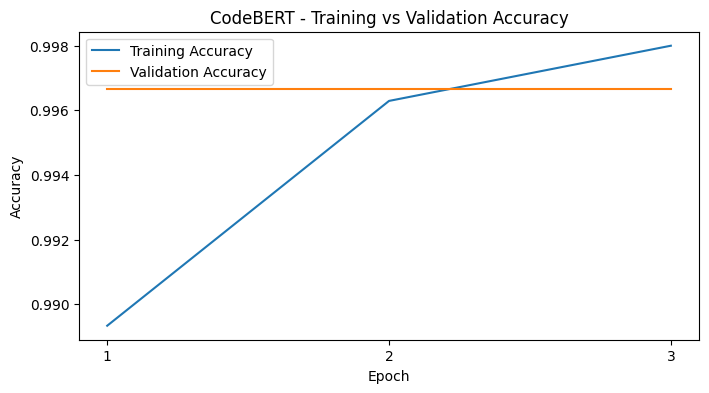

In [34]:
epochs = [1, 2, 3]

plt.figure(figsize=(8,4))

plt.plot(
    epochs,
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [val_accuracy] * len(epochs),
    label="Validation Accuracy"
)

plt.title(
    "CodeBERT - Training vs Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.xticks(epochs)

plt.legend()

plt.show()

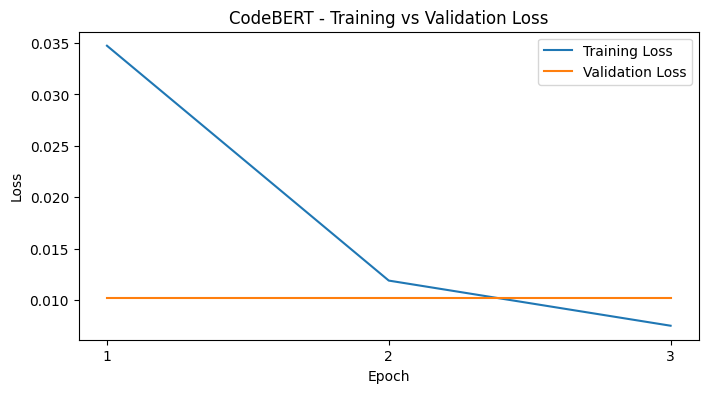

In [35]:
plt.figure(figsize=(8,4))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    [val_loss] * len(epochs),
    label="Validation Loss"
)

plt.title(
    "CodeBERT - Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(epochs)

plt.legend()

plt.show()

## 13. Generate test predictions

In [36]:
test_predictions = []
test_labels = []

model.eval()

with torch.no_grad():

    for batch in tqdm(ai_test_loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        logits = outputs.logits

        predictions = torch.argmax(
            logits,
            dim=1
        )

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_labels.extend(
            labels.cpu().numpy()
        )

100%|██████████| 375/375 [01:22<00:00,  4.57it/s]


## 14. Evaluate test (metrics)

In [37]:
test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_precision = precision_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

print("Test Results")
print("---------------------")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

Test Results
---------------------
Accuracy : 0.9957
Precision: 0.9957
Recall   : 0.9957
F1 Score : 0.9957


## 15. Create Confusion Matrix

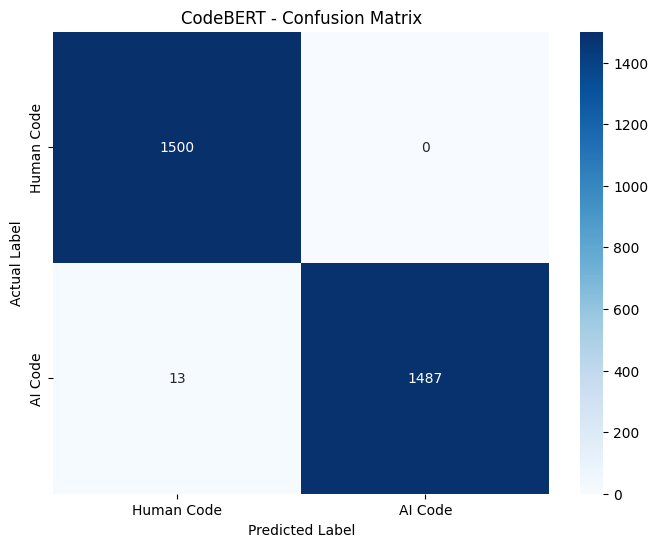

In [38]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human Code", "AI Code"],
    yticklabels=["Human Code", "AI Code"]
)

plt.title("CodeBERT - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()